In [1]:
# Imports and repo setup.
from pathlib import Path
from collections import Counter
from dataclasses import asdict, dataclass
from io import BytesIO
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names
from calvin_experiments.train_dynamics_world_model import load_dynamics_model_for_eval

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
cuda: True


In [2]:
# Load the policy, automaton world model, and local dynamics world model.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0001_epochs80_2026-05-04_17-15-26"
DYNAMICS_CKPT_PATH = REPO_ROOT / "outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/F_switch_G_safety"

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")
TARGET_LABEL_NAME = "switch_on"
TARGET_LABEL_IDX = label_names.index(TARGET_LABEL_NAME)
assert TARGET_LABEL_IDX == 0, f"Expected label 0 to be switch_on, got {TARGET_LABEL_IDX}"

dynamics_model, dynamics_stats, dynamics_ckpt, dynamics_meta = load_dynamics_model_for_eval(DYNAMICS_CKPT_PATH, device=DEVICE)
dynamics_model.eval()
dynamics_stats_t = {k: torch.as_tensor(v, device=DEVICE, dtype=torch.float32).unsqueeze(0) for k, v in dynamics_stats.items()}

print("device:", DEVICE)
print("labels:", label_names)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("dynamics:", DYNAMICS_CKPT_PATH)



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['eye_in_hand', 'third_person']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
labels: ['switch_on', 'button_on', 'drawer_open']
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0001_epochs80_2026-05-04_17-15-26
dynamics: /home/moritz/src/guided-diffusion/outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08


In [3]:
# Old rollout and sample-and-rank helpers, kept close to automaton_guidance_calvin.ipynb.
env = None
base_env_state = None

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def opposite_label_idx(target_label_idx):
    opposites = {
        "switch_on": "switch_off", "switch_off": "switch_on",
        "button_on": "button_off", "button_off": "button_on",
        "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
        "door_left": "door_right", "door_right": "door_left",
    }
    name = opposites.get(label_names[int(target_label_idx)])
    return None if name is None or name not in label_names else label_names.index(name)

def score_label_probs(label_probs, target_label_idx):
    scores = np.asarray(label_probs, dtype=np.float32)[..., int(target_label_idx)].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {k: v.repeat((int(n),) + (1,) * (v.ndim - 1)) for k, v in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {k: policy.action_normalization_stats[k]["offset"].shape[1:] for k in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    action_chunk_dim = len(automaton_stats["actions_mean"])
    automaton_horizon = action_chunk_dim // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=150, save_video=True, stop_on_behavior=True):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)

    CRU.seed_everything(seed)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = CRU.capture_scene_snapshot(env)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)

    actions, rewards, dones, records = [], [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    action_queue = []
    behavior, behavior_step, termination_reason = "none", -1, "horizon"

    for step in range(int(horizon)):
        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            behavior_step = step + 1
            if stop_on_behavior:
                termination_reason = "behavior"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed), "behavior": behavior,
        "behavior_step": int(behavior_step), "termination_step": len(actions), "termination_reason": termination_reason,
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "initial_label": label0.astype(int).tolist(),
        "final_label": labelf.astype(int).tolist(), "records": records, "scene_snapshot": scene_snapshot,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=30)
    return rollout


In [4]:
# STL robustness and dynamics-guided post-sample action refinement.
@dataclass
class SafetyBox:
    x_min: float = 0.20
    x_max: float = 0.25
    y_min: float = -0.175
    y_max: float = -0.125
    margin: float = 0.10

    def normalized(self):
        return SafetyBox(min(self.x_min, self.x_max), max(self.x_min, self.x_max), min(self.y_min, self.y_max), max(self.y_min, self.y_max), float(self.margin))

def euler_xyz_to_rot6d_torch(euler_xyz):
    x, y, z = euler_xyz[..., 0], euler_xyz[..., 1], euler_xyz[..., 2]
    sx, cx = torch.sin(x), torch.cos(x)
    sy, cy = torch.sin(y), torch.cos(y)
    sz, cz = torch.sin(z), torch.cos(z)
    return torch.stack([cz * cy, sz * cy, -sy, cz * sy * sx - sz * cx, sz * sy * sx + cz * cx, cy * sx], dim=-1)

def raw_env_state_to_dynamics_state_torch(robot, scene):
    robot_t = torch.as_tensor(robot, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    scene_t = torch.as_tensor(scene, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    robot_dyn = torch.cat([robot_t[..., :3], euler_xyz_to_rot6d_torch(robot_t[..., 3:6]), robot_t[..., 6:]], dim=-1)
    scene_parts = [scene_t[..., :6]]
    for start in (6, 12, 18):
        scene_parts += [scene_t[..., start:start + 3], euler_xyz_to_rot6d_torch(scene_t[..., start + 3:start + 6])]
    return torch.cat([robot_dyn, torch.cat(scene_parts, dim=-1)], dim=-1)

def project_rot6d_torch(rot6d):
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r1 = r1 / (torch.linalg.norm(r1, dim=-1, keepdim=True) + 1e-8)
    r2 = r2 - torch.sum(r1 * r2, dim=-1, keepdim=True) * r1
    r2 = r2 / (torch.linalg.norm(r2, dim=-1, keepdim=True) + 1e-8)
    return torch.cat([r1, r2], dim=-1)

def project_dynamics_state_torch(state):
    pieces, cursor = [], 0
    for start, end in [(3, 9), (27, 33), (36, 42), (45, 51)]:
        pieces += [state[..., cursor:start], project_rot6d_torch(state[..., start:end])]
        cursor = end
    return torch.cat(pieces + [state[..., cursor:]], dim=-1)

def dynamics_rollout_torch(state_dyn, action_chunk):
    if action_chunk.ndim == 2:
        action_chunk = action_chunk.unsqueeze(0)
    state = state_dyn.expand(action_chunk.shape[0], -1)
    states = []
    for t in range(action_chunk.shape[1]):
        state_n = (state - dynamics_stats_t["state_mean"]) / dynamics_stats_t["state_std"]
        action_n = (action_chunk[:, t, :] - dynamics_stats_t["action_mean"]) / dynamics_stats_t["action_std"]
        delta_n = dynamics_model(state_n, action_n)
        delta = delta_n * dynamics_stats_t["delta_std"] + dynamics_stats_t["delta_mean"]
        state = project_dynamics_state_torch(state + delta)
        states.append(state)
    return torch.stack(states, dim=1)

def signed_distance_to_box_torch(xy, safety_box):
    box = safety_box.normalized()
    center = torch.tensor([(box.x_min + box.x_max) / 2, (box.y_min + box.y_max) / 2], device=xy.device, dtype=xy.dtype)
    half = torch.tensor([(box.x_max - box.x_min) / 2, (box.y_max - box.y_min) / 2], device=xy.device, dtype=xy.dtype)
    q = torch.abs(xy - center) - half
    outside = torch.linalg.norm(torch.clamp(q, min=0.0), dim=-1)
    inside = torch.minimum(torch.maximum(q[..., 0], q[..., 1]), torch.zeros((), device=xy.device, dtype=xy.dtype))
    return outside + inside

def safety_robustness_torch(state_dyn, action_chunk, safety_box, smooth_min_tau=0.02):
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    pred_xy = pred_states[..., 0:2]
    signed_dist = signed_distance_to_box_torch(pred_xy, safety_box)
    capped = torch.clamp(signed_dist, max=float(safety_box.margin))
    tau = max(float(smooth_min_tau), 1e-6)
    smooth_min = -tau * torch.logsumexp(-capped / tau, dim=-1)
    return smooth_min, pred_xy, signed_dist

def refine_action_chunk_for_safety(robot, scene, action_chunk, safety_box, guidance_scale=0.5, gradient_steps=5, step_size=0.03, action_reg=0.05, smooth_min_tau=0.02):
    state_dyn = raw_env_state_to_dynamics_state_torch(robot, scene)
    original = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32)
    actions = original.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([actions], lr=float(step_size))
    history = []
    with torch.no_grad():
        robust_before, pred_xy_before, signed_before = safety_robustness_torch(state_dyn, original, safety_box, smooth_min_tau)
    for _ in range(int(gradient_steps)):
        opt.zero_grad(set_to_none=True)
        robust, _, _ = safety_robustness_torch(state_dyn, actions, safety_box, smooth_min_tau)
        action_penalty = torch.mean((actions - original) ** 2, dim=(1, 2))
        objective = float(guidance_scale) * robust - float(action_reg) * action_penalty
        (-objective.mean()).backward()
        opt.step()
        with torch.no_grad():
            actions.clamp_(-1.0, 1.0)
            history.append({"robustness": float(robust[0].detach().cpu()), "action_penalty": float(action_penalty[0].detach().cpu()), "objective": float(objective[0].detach().cpu())})
    with torch.no_grad():
        robust_after, pred_xy_after, signed_after = safety_robustness_torch(state_dyn, actions, safety_box, smooth_min_tau)
    record = {
        "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_after[0].cpu()),
        "min_signed_dist_before": float(signed_before[0].min().cpu()), "min_signed_dist_after": float(signed_after[0].min().cpu()),
        "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_after[0].detach().cpu().numpy().tolist(),
        "action_l2_change": float(torch.linalg.norm(actions - original).detach().cpu()), "history": history,
    }
    return actions[0].detach().cpu().numpy().astype(np.float32), record

def make_stl_action_sampler(target_label_idx, n_candidates, safety_box, guidance_scale=0.5, gradient_steps=5, step_size=0.03, action_reg=0.05, smooth_min_tau=0.02):
    def action_sampler(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
        candidate_scores = score_label_probs(candidate_probs, target_label_idx)
        selected_idx = int(np.argmax(candidate_scores))
        selected = np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32)
        state = env.get_state()
        refined, safety = refine_action_chunk_for_safety(
            state["robot"], state["scene"], selected, safety_box,
            guidance_scale=guidance_scale, gradient_steps=gradient_steps, step_size=step_size, action_reg=action_reg, smooth_min_tau=smooth_min_tau,
        )
        record = {
            "t": int(step), "selected_idx": selected_idx, "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, target_label_idx]), "pred_probs": candidate_probs[selected_idx].tolist(),
            "candidate_scores": candidate_scores.tolist(), "safety": safety,
        }
        return refined, record
    return action_sampler

def path_enters_safety_box(eef_xy, safety_box):
    box = safety_box.normalized(); xy = np.asarray(eef_xy, dtype=np.float32)
    return bool(np.any((xy[:, 0] >= box.x_min) & (xy[:, 0] <= box.x_max) & (xy[:, 1] >= box.y_min) & (xy[:, 1] <= box.y_max)))


In [16]:
# Experiment knobs and rollout loop. Edit this cell for tuning; it runs every (seed, guidance_scale) pair.
SEEDS = list(range(0, 5))
GUIDANCE_SCALES = [0.0]
N_CANDIDATES = 1
HORIZON = 150
SAVE_VIDEO = True

# CALVIN tabletop y coordinates in the diagnostics plot are around -0.3..0.2.
SAFETY_BOX = SafetyBox(x_min=0.225, x_max=0.275, y_min=-0.125, y_max=-0.075, margin=0.02)
GRADIENT_STEPS = 10 
STEP_SIZE = 0.03
ACTION_REG = 0.05
SMOOTH_MIN_TAU = 0.02

def scale_tag(scale):
    return f"scale_{float(scale):.3g}".replace("-", "m").replace(".", "p")

run_dir = OUTPUT_ROOT / time.strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=False)

rollouts = []
for guidance_scale in GUIDANCE_SCALES:
    action_sampler = make_stl_action_sampler(
        TARGET_LABEL_IDX, N_CANDIDATES, SAFETY_BOX,
        guidance_scale=guidance_scale, gradient_steps=GRADIENT_STEPS, step_size=STEP_SIZE,
        action_reg=ACTION_REG, smooth_min_tau=SMOOTH_MIN_TAU,
    )
    for seed in SEEDS:
        tag = f"F_switch_G_safety_{scale_tag(guidance_scale)}_seed_{seed:03d}"
        rollout = rollout_policy_once(seed, action_sampler, run_dir, tag, horizon=HORIZON, save_video=SAVE_VIDEO)
        rollout["guidance_scale"] = float(guidance_scale)
        rollout["safety_violation"] = path_enters_safety_box(rollout["eef_xy"], SAFETY_BOX)
        rollouts.append(rollout)
        print(
            f"scale={guidance_scale:>5g} seed {seed:03d}: behavior={rollout['behavior']:>10} "
            f"@ {rollout['behavior_step']:>3}, safe={not rollout['safety_violation']}, video={rollout.get('video')}"
        )

per_scale = {}
for guidance_scale in GUIDANCE_SCALES:
    scale_rollouts = [r for r in rollouts if r["guidance_scale"] == float(guidance_scale)]
    per_scale[str(float(guidance_scale))] = {
        "n": len(scale_rollouts),
        "behavior_counts": dict(Counter(r["behavior"] for r in scale_rollouts)),
        "target_success_rate": sum(r["behavior"] == TARGET_LABEL_NAME for r in scale_rollouts) / max(1, len(scale_rollouts)),
        "safe_rate": sum(not r["safety_violation"] for r in scale_rollouts) / max(1, len(scale_rollouts)),
    }

summary = {
    "seeds": SEEDS, "guidance_scales": [float(s) for s in GUIDANCE_SCALES],
    "n_rollouts": len(rollouts), "behavior_counts": dict(Counter(r["behavior"] for r in rollouts)),
    "target_success_rate": sum(r["behavior"] == TARGET_LABEL_NAME for r in rollouts) / max(1, len(rollouts)),
    "safe_rate": sum(not r["safety_violation"] for r in rollouts) / max(1, len(rollouts)),
    "per_scale": per_scale,
    "safety_box": asdict(SAFETY_BOX.normalized()),
    "guidance": {"gradient_steps": GRADIENT_STEPS, "step_size": STEP_SIZE, "action_reg": ACTION_REG, "smooth_min_tau": SMOOTH_MIN_TAU},
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("run_dir:", run_dir)


ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=    0 seed 000: behavior= switch_on @  78, safe=False, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_safety/20260506_125736/F_switch_G_safety_scale_0_seed_000/blocks_hidden_F_switch_G_safety_scale_0_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=    0 seed 001: behavior=      none @  -1, safe=True, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_safety/20260506_125736/F_switch_G_safety_scale_0_seed_001/blocks_hidden_F_switch_G_safety_scale_0_seed_001_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=    0 seed 002: behavior=drawer_open @  63, safe=True, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_safety/20260506_125736/F_switch_G_safety_scale_0_seed_002/blocks_hidden_F_switch_G_safety_scale_0_seed_002_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
scale=   

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_switch_G_safety/20260506_125736/rollouts_xy.png


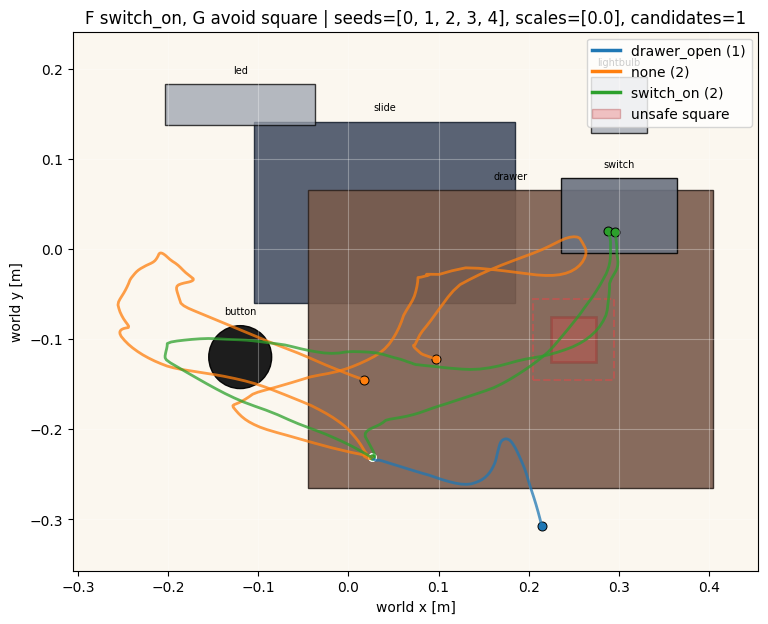

In [17]:
# Plot all rollout paths with the unsafe square and safety margin.
def plot_rollout_xy_with_safety(rollouts, scene_snapshot, safety_box, title, save_path=None):
    paths = [np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts]
    behaviors = [r["behavior"] for r in rollouts]
    scales = [r.get("guidance_scale") for r in rollouts]
    label_by_scale = len({s for s in scales if s is not None}) > 1
    path_labels = [f"scale={s:g} {b}" if label_by_scale and s is not None else b for s, b in zip(scales, behaviors)]
    colors = {label: plt.get_cmap("tab10")(i) for i, label in enumerate(sorted(set(path_labels)))}
    box = safety_box.normalized()
    all_xy = np.concatenate(paths, axis=0)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)
    ax.add_patch(Rectangle((box.x_min, box.y_min), box.x_max - box.x_min, box.y_max - box.y_min, facecolor="#ef4444", edgecolor="#991b1b", alpha=0.28, linewidth=2, label="unsafe square"))
    ax.add_patch(Rectangle((box.x_min - box.margin, box.y_min - box.margin), box.x_max - box.x_min + 2 * box.margin, box.y_max - box.y_min + 2 * box.margin, facecolor="none", edgecolor="#ef4444", alpha=0.45, linestyle="--", linewidth=1.4, label="safety margin"))
    for rollout, xy, path_label in zip(rollouts, paths, path_labels):
        color = colors[path_label]
        ax.plot(xy[:, 0], xy[:, 1], color=color, linewidth=2, alpha=0.75)
        ax.scatter(xy[0, 0], xy[0, 1], c=[color], s=28, edgecolors="white", linewidths=0.7)
        ax.scatter(xy[-1, 0], xy[-1, 1], c=[color], s=42, edgecolors="black", linewidths=0.7)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, np.vstack([all_xy, [[box.x_min, box.y_min], [box.x_max, box.y_max]]]))
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title); ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]"); ax.grid(alpha=0.3)
    handles = [Line2D([0], [0], color=colors[label], lw=2.5, label=f"{label} ({path_labels.count(label)})") for label in sorted(set(path_labels))]
    handles.append(Rectangle((0, 0), 1, 1, facecolor="#ef4444", edgecolor="#991b1b", alpha=0.28, label="unsafe square"))
    ax.legend(handles=handles, loc="upper right")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
    png = BytesIO(); fig.savefig(png, format="png", dpi=100, bbox_inches="tight"); plt.close(fig)
    display(Image(data=png.getvalue()))

plot_rollout_xy_with_safety(
    rollouts, rollouts[0]["scene_snapshot"], SAFETY_BOX,
    title=f"F switch_on, G avoid square | seeds={SEEDS}, scales={GUIDANCE_SCALES}, candidates={N_CANDIDATES}",
    save_path=run_dir / "rollouts_xy.png",
)


In [12]:
# Quick diagnostics for the predicted local robustness updates.
rows = []
for rollout in rollouts:
    for record in rollout.get("records", []):
        safety = record["safety"]
        rows.append({
            "seed": rollout["seed"], "t": record["t"], "score": record["selected_score"],
            "target_prob": record["selected_target_prob"], "robust_before": safety["robust_before"],
            "robust_after": safety["robust_after"], "min_dist_before": safety["min_signed_dist_before"],
            "min_dist_after": safety["min_signed_dist_after"], "action_l2_change": safety["action_l2_change"],
        })

print("n refinement calls:", len(rows))
for row in rows[:10]:
    print(row)
if rows:
    print("median robustness improvement:", float(np.median([r["robust_after"] - r["robust_before"] for r in rows])))
    print("max action L2 change:", float(np.max([r["action_l2_change"] for r in rows])))

CRU.drop_env_quietly(globals(), name="env")


n refinement calls: 69
{'seed': 0, 't': 0, 'score': 0.21917890012264252, 'target_prob': 0.21917890012264252, 'robust_before': -0.021588830277323723, 'robust_after': -0.021588830277323723, 'min_dist_before': 0.18359710276126862, 'min_dist_after': 0.18359710276126862, 'action_l2_change': 0.0}
{'seed': 0, 't': 8, 'score': 0.5696542263031006, 'target_prob': 0.5696542263031006, 'robust_before': -0.021588830277323723, 'robust_after': -0.021588830277323723, 'min_dist_before': 0.14861975610256195, 'min_dist_after': 0.14861975610256195, 'action_l2_change': 0.0}
{'seed': 0, 't': 16, 'score': 0.9487410187721252, 'target_prob': 0.9487410187721252, 'robust_before': -0.021588830277323723, 'robust_after': -0.021588830277323723, 'min_dist_before': 0.04668136686086655, 'min_dist_after': 0.04668136686086655, 'action_l2_change': 0.0}
{'seed': 0, 't': 24, 'score': 0.9879782199859619, 'target_prob': 0.9879782199859619, 'robust_before': -0.025960760191082954, 'robust_after': -0.025960760191082954, 'min_dist